<a href="https://colab.research.google.com/github/nikhilkudavemnh/classic-ML/blob/main/classicMl/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 Problem: Predicting Housing Prices with Multicollinearity & Feature Engineering

You are given a dataset containing information about **1,000 houses**. The goal is to build a regression model to predict house prices while addressing common real-world challenges such as multicollinearity, interaction effects, non-linearity, and heteroscedasticity.

## Dataset

| Feature | Description |
|---------|-------------|
| `size_sqft` | Total size of the house in square feet |
| `living_area_sqft` | Living area in square feet (~85% of total size) |
| `bedrooms` | Number of bedrooms |
| `bathrooms` | Number of bathrooms |
| `age_years` | Age of the house in years |
| `renovated` | `1` if renovated in the last 10 years, otherwise `0` |
| `distance_downtown_km` | Distance from the city center (in km) |
| `school_rating` | Nearby school rating (1–10) |
| `price` | **Target variable** |

---

## Challenges Built Into the Dataset

### 1. Multicollinearity
The features `size_sqft` and `living_area_sqft` are **highly correlated** (correlation ≈ **0.95**).

- Detect multicollinearity using:
  - Correlation Matrix
  - Variance Inflation Factor (VIF)
- Decide how to handle the correlated features.

---

### 2. Interaction Effect
The effect of `school_rating` on house price is **stronger for houses closer to downtown**.

Create an interaction feature:

```python
school_distance_interaction = school_rating * (1 / distance_downtown_km)
```

Use this feature in your regression model.

---

### 3. Non-Linearity
House prices generally **decrease as houses get older**, but **very old (vintage) houses**—those older than **80 years**—become valuable again.

A simple linear relationship may not capture this behavior.

Possible feature engineering approaches:

```python
age_squared = age_years ** 2
```

or

```python
is_vintage = 1 if age_years > 80 else 0
```

---

### 4. Heteroscedasticity
The variance of house prices **increases with house size**.

This means:

- Small houses → Lower variance in prices
- Large houses → Higher variance in prices

As a result, the assumptions of Ordinary Least Squares (OLS) may be violated.

---

## Tasks

### Task 1: Exploratory Data Analysis (EDA)

1. Compute the correlation matrix.
2. Visualize correlations using a heatmap.
3. Identify highly correlated feature pairs.
4. Calculate VIF scores.

**Expected Outcome:**
- Detect multicollinearity between:
  - `size_sqft`
  - `living_area_sqft`

---

### Task 2: Feature Engineering

Create the following features:

#### Interaction Feature

```python
school_distance_interaction = school_rating * (1 / distance_downtown_km)
```

#### Non-linear Feature

Choose one:

```python
age_squared = age_years ** 2
```

OR

```python
is_vintage = (age_years > 80).astype(int)
```

---

### Task 3: Build and Diagnose the Model

1. Fit an **Ordinary Least Squares (OLS)** regression model.
2. Examine:
   - Coefficients
   - P-values
   - R² score
3. Plot:

```text
Residuals vs Fitted Values
```

Check for:

- Funnel-shaped residuals
- Increasing variance
- Non-random patterns

These indicate **heteroscedasticity**.

---

### Task 4: Fix Heteroscedasticity

Try one or both approaches:

#### Option A: Log Transformation

```python
log_price = np.log(price)
```

Train the model on:

```python
y = log_price
```

---

#### Option B: Weighted Least Squares (WLS)

Assign weights inversely proportional to variance:

```python
weights = 1 / size_sqft
```

Then fit:

```python
sm.WLS(y, X, weights=weights)
```

---

### Task 5: Compare Models

Compare the original OLS model with the improved model.

Report:

| Metric | OLS | Improved Model |
|-------|------|----------------|
| R² | | |
| RMSE | | |
| Adjusted R² | | |
| VIF | | |
| Residual Pattern | | |

---

## Deliverables

Your final submission should include:

- ✅ Correlation Matrix
- ✅ Heatmap of Features
- ✅ VIF Calculation
- ✅ Engineered Features
- ✅ OLS Regression Summary
- ✅ Residual vs Fitted Plot
- ✅ WLS or Log-Transformed Model
- ✅ Comparison Table
- ✅ Interpretation of Results

---

## Bonus Challenge

1. Apply **Ridge Regression** to handle multicollinearity.
2. Compare:
   - OLS
   - Ridge Regression
   - WLS
3. Explain:
   - Which model performs best?
   - Why?
   - How multicollinearity affected coefficient estimates?

---
**Difficulty:** ⭐⭐⭐⭐☆ (Intermediate to Advanced)  
**Topics Covered:** Linear Regression, Feature Engineering, Multicollinearity, Interaction Terms, Heteroscedasticity, WLS, VIF, Ridge Regression

In [1]:
## dataset creation
import numpy as np
import pandas as pd

np.random.seed(42)
N = 1000

size_sqft = np.random.randint(800, 3000, N)
living_area_sqft = (size_sqft * np.random.uniform(0.80, 0.90, N)).astype(int)
bedrooms = np.random.randint(1, 6, N)
bathrooms = np.random.randint(1, 5, N)
age_years = np.random.randint(1, 101, N)
renovated = ((age_years > 20) & (np.random.rand(N) > 0.6)).astype(int)
distance_downtown_km = np.round(np.random.uniform(1, 30, N), 1)
school_rating = np.round(np.random.uniform(1, 10, N), 1)

price = (
    50000
    + living_area_sqft * 120
    + bedrooms * 8000
    + bathrooms * 12000
    - age_years * 800
    + renovated * 25000
    - distance_downtown_km * 3000
    + school_rating * 8000
    + (school_rating / distance_downtown_km) * 15000   # INTERACTION
    + np.where(age_years > 80, 40000, 0)               # NON-LINEAR
    + living_area_sqft * 20 * np.random.randn(N)       # HETEROSCEDASTICITY
)
price = np.maximum(80000, price).astype(int)

df = pd.DataFrame({
    'size_sqft': size_sqft,
    'living_area_sqft': living_area_sqft,
    'bedrooms': bedrooms, 'bathrooms': bathrooms,
    'age_years': age_years, 'renovated': renovated,
    'distance_downtown_km': distance_downtown_km,
    'school_rating': school_rating, 'price': price
})
df.to_csv('housing.csv', index=False)
print(df.head())

   size_sqft  living_area_sqft  bedrooms  bathrooms  age_years  renovated  \
0       1660              1466         4          3         85          0   
1       2094              1881         4          4         66          0   
2       1930              1645         2          3          6          0   
3       1895              1548         2          3         18          0   
4       2438              2016         3          1         94          1   

   distance_downtown_km  school_rating   price  
0                  25.0            4.9  195554  
1                  21.2            5.7  266160  
2                  27.8            2.8  241778  
3                  24.8            7.8  273514  
4                  17.3            7.7  305707  


In [3]:
df.head()


,size_sqft,living_area_sqft,bedrooms,bathrooms,age_years,renovated,distance_downtown_km,school_rating,price
0,1660,1466,4,3,85,0,25.0,4.9,195554
1,2094,1881,4,4,66,0,21.2,5.7,266160
2,1930,1645,2,3,6,0,27.8,2.8,241778
3,1895,1548,2,3,18,0,24.8,7.8,273514
4,2438,2016,3,1,94,1,17.3,7.7,305707


In [4]:
df.describe()

,size_sqft,living_area_sqft,bedrooms,bathrooms,age_years,renovated,distance_downtown_km,school_rating,price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1931.344000,1642.497000,3.033000,2.465000,50.983000,0.311000,15.116900,5.505200,285894.851000
std,632.192904,541.500355,1.421947,1.123404,28.393466,0.463134,8.327206,2.582875,89704.074015
min,801.000000,647.000000,1.000000,1.000000,1.000000,0.000000,1.100000,1.000000,80000.000000
25%,1415.750000,1192.750000,2.000000,1.000000,26.000000,0.000000,7.900000,3.300000,216965.750000
50%,1941.000000,1642.000000,3.000000,2.000000,53.000000,0.000000,15.050000,5.600000,284203.000000
75%,2482.000000,2116.750000,4.000000,3.000000,76.000000,1.000000,22.125000,7.600000,345307.000000
max,2999.000000,2682.000000,5.000000,4.000000,100.000000,1.000000,30.000000,10.000000,571824.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   size_sqft             1000 non-null   int64  
 1   living_area_sqft      1000 non-null   int64  
 2   bedrooms              1000 non-null   int64  
 3   bathrooms             1000 non-null   int64  
 4   age_years             1000 non-null   int64  
 5   renovated             1000 non-null   int64  
 6   distance_downtown_km  1000 non-null   float64
 7   school_rating         1000 non-null   float64
 8   price                 1000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 70.4 KB


## Step 2: Correlation Matrix (Find Multicollinearity)

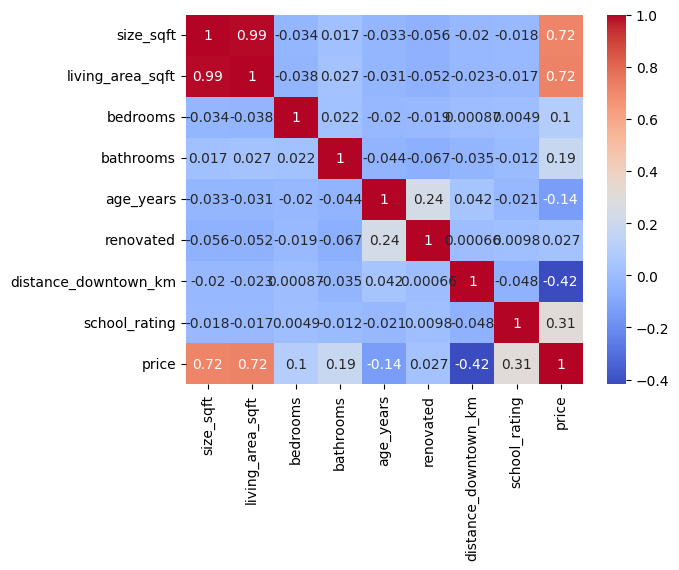

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap = "coolwarm")
plt.show()

In [10]:
# drop living_area_sqft

df = df.drop('living_area_sqft', axis=1)
df

,size_sqft,bedrooms,bathrooms,age_years,renovated,distance_downtown_km,school_rating,price
0,1660,4,3,85,0,25.0,4.9,195554
1,2094,4,4,66,0,21.2,5.7,266160
2,1930,2,3,6,0,27.8,2.8,241778
3,1895,2,3,18,0,24.8,7.8,273514
4,2438,3,1,94,1,17.3,7.7,305707
...,...,...,...,...,...,...,...,...
995,1320,4,4,20,0,11.0,2.0,224287
996,1036,3,3,100,1,1.6,5.6,340002
997,2104,5,1,35,0,21.0,7.6,324737
998,2581,4,1,32,0,28.4,9.9,272974
